# Sensitivities

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cr3bp import (
    create_earth_moon_system,
    grid_search_method,
    sweep_2d,
    contour_plot
    )

In [ ]:
from scipy.interpolate import griddata


def contour_plot(x, y, z, levels=20, cmap='viridis', method='cubic',
                 grid_res=200, filled=True, xlabel='x', ylabel='y',
                 title=None, figsize=(8, 6)):
    xi = np.linspace(x.min(), x.max(), grid_res)
    yi = np.linspace(y.min(), y.max(), grid_res)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((x, y), z, (Xi, Yi), method=method)

    fig, ax = plt.subplots(figsize=figsize)
    plot_func = ax.contourf if filled else ax.contour
    cs = plot_func(Xi, Yi, Zi, levels=levels, cmap=cmap)
    fig.colorbar(cs, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)

    return fig, ax

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

In [7]:
optimals = np.load("optimals_iteration2.npy")
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.9738227146814404
Optimal delta_v: 3.0242382271468142
Optimal delta_v_angle: 0.0696875
Optimal tof: 0.72910225921522


In [31]:
theta_delta = 0.001

delta_v_delta = 0.002

delta_v_angle_delta = 0.0001

tof_delta = 0.0001

## Theta v Delta_v

In [ ]:
results_df = sweep_2d(em, 'theta', theta_delta, 'delta_v', delta_v_delta, 202, optimals, leo_alt_m, lmo_alt_m)
print(results_df.head())

Performing grid search with 202 x 202 x 1 x 1 = 40804 grid points...
Iteration: 2074/40804
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=-0.08 km, Total Delta_v=4.08 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.97 rad, Delta_v_angle=0.07 rad, TOF=0.73 s, Distance to LMO=-0.08 km
Iteration: 3541/40804
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.83 km, Total Delta_v=3.13 km/s
New optimal found: Delta_v=3.10 km/s, Theta=3.97 rad, Delta_v_angle=0.07 rad, TOF=0.73 s, Distance to LMO=0.83 km
Iteration: 3743/40804
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.10 km, Total Delta_v=3.13 km/s
Iteration: 3894/40804
Grid point satisfies constraint: Theta=3.97 rad, Delta_v=3.02, Delta_v_angle=0.07 rad, TOF=0.73 s => Distance to LMO=0.54 km, Total Delta_v=4.05 km/s
Iteration: 39

In [28]:
print(results_df.head())

theta = results_df['theta'].values
delta_v = results_df['delta_v'].values
total_delta_v = results_df['total_delta_v'].values

      theta   delta_v  delta_v_angle       tof  total_delta_v  distance_to_lmo
0  3.972863  3.024318       0.069687  0.729102       3.052159     2.052742e-06
1  3.973503  3.024318       0.069687  0.729102       3.200993    -4.176657e-07
2  3.973823  3.024238       0.069687  0.729102       3.331544     1.447516e-06
3  3.973943  3.024138       0.069687  0.729102       3.427402    -2.275470e-06
4  3.973963  3.024098       0.069687  0.729102       3.460319    -7.202096e-07


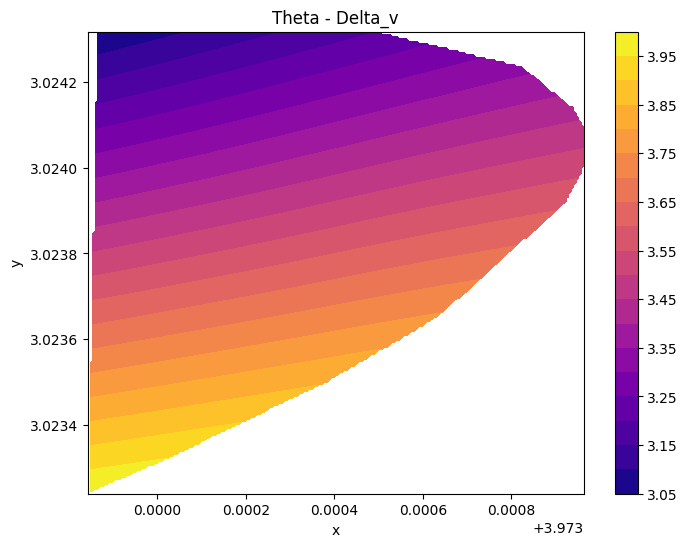

In [29]:
fig, ax = contour_plot(theta, delta_v, total_delta_v, title='Theta - Delta_v', cmap='plasma')
plt.show()

## Theta v Alpha

## Theta v ToF

## Delta_v v Alpha

## Delta_v v ToF

## Alpha v ToF